# AAI-500 Final Team Project - Team 1 - Olena McMurtrey
### Week 5 Draft
#### **Research question** 
  * Examine how response time varies across models and request characteristics, and identify patterns that may be useful for model selection in a multi-model workflow. 
#### **Focus area**: 
  * Response time, CPU and memory across four models.
#### Date: 10/4/26
*Data file:* Olena_Log_Template_Proposed.csv
  * *Response time* - model_time_seconds
    * Main measure, whole seconds, observed range 2 to 246
  * *CPU usage* - cpu_avg_pct
    * Average CPU during the call, observed range 31.3 to 212.8
  * *Memory usage* - memory_avg_mb
    * Average memory during the call, about 7,700 MB
  * *Model* - 4 modeles:
    * *gemma-3-12b-it* - Gemma 3 12B Instruct
      * It supports multimodal input of text plus images, outputs text, and handles a 128,000-token context.
    * *pixtral-12b* - Pixtral 12B
      * Mistral AI's vision-language model, with roughly 12 billion parameters in its decoder and about 400 million more in a custom vision encoder. Mistral now lists it as deprecated and no longer maintained.
    * *minicpm-o-2_6* - MiniCPM-o 2.6
      * Built end-to-end from SigLip-400M, Whisper-medium-300M, ChatTTS-200M and Qwen2.5-7B, totalling 8B parameters.
    * *qwen2-vl-7b-instruct* - Qwen2-VL 7B Instruct
      * The 7-billion-parameter instruction-tuned vision-language model from Alibaba's Qwen team.


In [84]:
# Import all libraries collection needed for the project
# import pandas libraries
import pandas as pd
# Import seaborn for the plots and matplotlib for the figure layout.
import seaborn as sns
import matplotlib.pyplot as plt
# gamma supplies the probability density function to draw
from scipy.stats import gamma
# Import the chi-squared test
from scipy.stats import chi2_contingency
# Import more libraries
import pandas as pd # for data science
import numpy as np  # linear algebra library
import matplotlib.pyplot as plt # plotting library
# import stats functions
from scipy import stats
# probplot compares observed quantiles against theoretical quantiles
from scipy.stats import probplot
# pyplot is the module probplot draws into
from matplotlib import pyplot
# import normal continuous random variable
from scipy.stats import norm
# Import the t distribution object for the cutoff value.
from scipy.stats import t
#Import the statsmodels stats interface 
import statsmodels.stats.api as sms
# Import the proportion test
from statsmodels.stats.proportion import proportions_ztest
# Import the beta distribution object
from scipy.stats import beta
# Import for Bayesian structure, score base
from pgmpy.causal_discovery import HillClimbSearch, ExpertKnowledge
from pgmpy.models import DiscreteBayesianNetwork
from IPython.display import Image
# Import for constraint-based
from pgmpy.causal_discovery import PC
# Import the model class that holds the graph and its probability tables
from pgmpy.models import DiscreteBayesianNetwork
# Import the inference engine - Module 5 Lab does
from pgmpy.inference import VariableElimination
# Import the scoring functions.
# Import the scoring functions and the splitter.
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
# For image
from IPython.display import Image

In [7]:
# Check the file
# path to the cleaned file
clean_csv_path = '/Users/olenamcmurtrey/Downloads/Olena_Log_Template_Proposed.csv'
# read the cleaned file into a table
logs = pd.read_csv(clean_csv_path)
# rows and columns in the cleaned file
file_shape = logs.shape
# check results (rows, columns)
file_shape

(600, 30)

# Descriptive analyses (Response Time, CPU, Memory)

In [10]:
# keep only the runs where the model ran and returned an answer
completed_runs = logs.loc[logs['success'] == 'Yes']
# how many runs passed the filter
number_of_completed_runs = len(completed_runs)
# how many completed runs belong to each model
completed_runs_per_model = completed_runs['model'].value_counts()
# Prep for print from filter results
filter_sentence = (
    'Out of the 600 logged runs, ' + str(number_of_completed_runs) + ' completed and are used for every statistic below.')
print(filter_sentence)
# Check total data per model for the project
completed_runs_per_model

Out of the 600 logged runs, 460 completed and are used for every statistic below.


model
minicpm-o-2_6           115
gemma-3-12b-it          115
pixtral-12b             115
qwen2-vl-7b-instruct    115
Name: count, dtype: int64

## Response time by model - model_time_seconds
  * The single table gives the center, the standard deviation, the min, max, and quantiles for all four models at a glance.

  * It is an exploratory answer to how response time varies across four models. The mean says which model is typically faster; the standard deviation and quartiles say whether that advantage is consistent.

  *  `.groupby('model')` splits the rows into one group per model. `['model_time_seconds']` selects the column to summarise inside each group. `.describe()` returns count, mean, standard deviation, minimum, the three quartiles, and maximum, once per group. `groupby` sorts the groups by name, and rows with a missing grouping value are dropped.

  *  **Findings Notes:** Mean response time runs from 11.77 seconds for qwen2-vl-7b-instruct to 71.84 seconds for gemma-3-12b-it, with minicpm-o-2_6 at 17.87 and pixtral-12b at 42.45. The spread grows with the center: the standard deviation rises from 8.20 seconds for the fastest model to 56.72 for the slowest, so the slower models are also the less predictable ones. In most models, the mean sits above the median (minicpm-o-2_6 is almost the same), which is a sign of a right tail.

In [25]:
# five-number summary of response time for each of the four models
response_time_by_model = (
    completed_runs.groupby('model')['model_time_seconds'].describe()
)
print('Response time by model - model_time_seconds.\n'
'The single table gives the center, the standard deviation,\n'
      'the min, max, and quantiles for all four models at a glance.')
response_time_by_model

Response time by model - model_time_seconds.
The single table gives the center, the standard deviation,
the min, max, and quantiles for all four models at a glance.


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
gemma-3-12b-it,115.0,71.843478,56.718076,4.0,34.0,46.0,113.5,246.0
minicpm-o-2_6,115.0,17.869565,10.942851,2.0,10.0,17.0,23.5,59.0
pixtral-12b,115.0,42.452174,32.349583,3.0,17.5,31.0,55.0,122.0
qwen2-vl-7b-instruct,115.0,11.765217,8.203904,2.0,5.0,7.0,17.0,33.0


## Side-by-side box plots of response time by model

  * A table of eight statistics per model is hard to read as a comparison. One figure puts the four distributions on the same axis so the separation and the tails can be easily seen.
  *  It shows the area a mean cannot express - how far the slow runs reach. That is an important observation of how response time varies across models.
  *  A model with a heavy tail produces occasional very slow responses, which is a different operational risk from one that is average.
  *  `x` is the quantitative variable and `y` is the grouping variable, so one box is drawn per model's value of `y`. `data` is the table both column names refer to. `orient='h'` draws the boxes horizontally.
    
  *  **Findings:**
  *  The four boxes returned very different results, which is visible evidence of a real difference between models. The range for gemma-3-12b-it is wider than the entire observed range of qwen2-vl-7b-instruct model. Every model shows points beyond the upper whisker and none below the lower one, which suggests a right-skewed distribution.

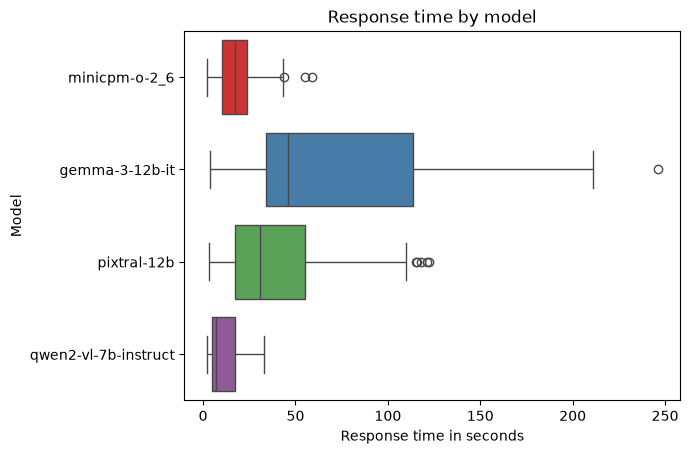

In [16]:
# one horizontal box plot per model, drawn on shared axes
sns.boxplot(x='model_time_seconds', y='model', 
            data=completed_runs, palette='Set1', hue='model', orient='h')
plt.xlabel('Response time in seconds')
plt.ylabel('Model')
plt.title('Response time by model')
plt.show()

## CPU and Memory utilization summary by model

  * Knowing a response time by model is not enough to decide which model performs faster. If the faster model consumes more resources, the choice becomes a trade-off. Measuring CPU usage and memory utilization helps validate the hypothesis about the model’s performance.

  * Our research question asks what the variation implies for model selection, and resource use helps to evaluate this.

  * Memory per call sets how many calls fit on the host at once, and CPU sets how much headroom remains free under load. Together they can help to decide what hardware the deployment needs for each model.

  * **Findings.** The four models have very similar readings for CPU and Memory utilizations measures, which is the opposite of what Response time by model showed in the previous analysis for "Response time by model". CPU means span 1.5 percentage points, from 114.84 to 116.36. Memory means span 19 MB, from 7,696 to 7,716. In both cases, the differences between models are not significant compare to the analysis of "Response time by model". Same is observed for Memory utilization measures.


In [26]:
# CPU usage summary for each model
cpu_usage_by_model = (
    completed_runs.groupby('model')['cpu_avg_pct'].describe()
)
print('CPU Usage by model.\n'
'The single table gives the center, the standard deviation,\n'
      'the min, max, and quantiles for all four models at a glance.')
cpu_usage_by_model

CPU Usage by model.
The single table gives the center, the standard deviation,
the min, max, and quantiles for all four models at a glance.


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
gemma-3-12b-it,115.0,115.762957,36.534224,33.03,93.665,115.00,133.000,208.18
minicpm-o-2_6,115.0,114.839565,38.034387,31.29,92.985,115.33,131.975,212.78
pixtral-12b,115.0,115.926261,34.549055,35.43,93.745,115.50,133.695,210.79
qwen2-vl-7b-instruct,115.0,116.358348,34.385015,36.00,93.575,116.00,131.960,212.00


In [27]:
# Memory usage summary for each model
memory_usage_by_model = (
    completed_runs.groupby('model')['memory_avg_mb'].describe()
)
print('Memory Usage by model.\n'
'The single table gives the center, the standard deviation,\n'
      'the min, max, and quantiles for all four models at a glance.')
memory_usage_by_model

Memory Usage by model.
The single table gives the center, the standard deviation,
the min, max, and quantiles for all four models at a glance.


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
gemma-3-12b-it,115.0,7703.956522,210.220243,7104.0,7604.5,7761.0,7801.5,8026.0
minicpm-o-2_6,115.0,7696.139130,217.558699,7007.0,7594.5,7757.0,7794.0,8025.0
pixtral-12b,115.0,7715.573913,203.229887,7141.0,7604.0,7765.0,7814.0,8041.0
qwen2-vl-7b-instruct,115.0,7714.591304,197.907514,7186.0,7602.0,7761.0,7814.0,8034.0


## Correlation between Response time and Resource use

  * We are asking a different question now: within the whole dataset, do slow calls cost more than fast ones?

  * If response time and resource use told the same story, one number would summarise both. If they do not, we can explore treating them  separately.

  *  We can explore whether speed and cost can be optimized independently, or whether routing away from slow requests also saves capacity.

  *  `.corr()` returns Pearson correlations for every pair of numeric columns. In `.plot`, `kind='scatter'` selects the plot type, `x` and `y` name the columns, `color` sets the marker color, and `figsize` sets the size in inches.

  *  **Findings:**

  *  All three correlations are effectively close to zero: 0.045 between response time and CPU, 0.004 between response time and memory, and 0.098 between the two resource measures. A call lasting 246 seconds consumes no more measured CPU or memory than one lasting 2 seconds. The scatter plot shows no trend in any direction. This is the second notable reading that the resource columns may be recording host-level load rather than the work of the individual call.

In [30]:
# the three measures we are exploring
speed_and_resource_measures = completed_runs[['model_time_seconds',
                                              'cpu_avg_pct',
                                              'memory_avg_mb']]

# correlation for every pair of those three measures
correlations_between_measures = speed_and_resource_measures.corr()
print('Correlation between Response time and Resource use:')
correlations_between_measures

Correlation between Response time and Resource use:


,model_time_seconds,cpu_avg_pct,memory_avg_mb
model_time_seconds,1.000000,0.044666,0.003556
cpu_avg_pct,0.044666,1.000000,0.098061
memory_avg_mb,0.003556,0.098061,1.000000


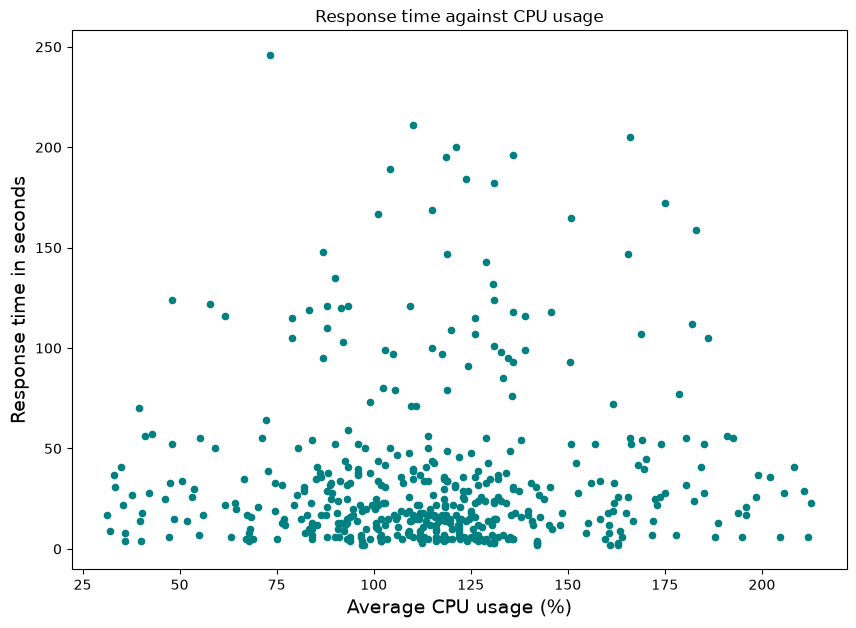

In [32]:
# scatter plot of Response Time against CPU usage
completed_runs.plot(kind='scatter', x='cpu_avg_pct',
                    y='model_time_seconds', color='teal',
                    figsize=(10, 7))
plt.xlabel('Average CPU usage (%)', size=14)
plt.ylabel('Response time in seconds', size=14)
plt.title('Response time against CPU usage')
plt.show()

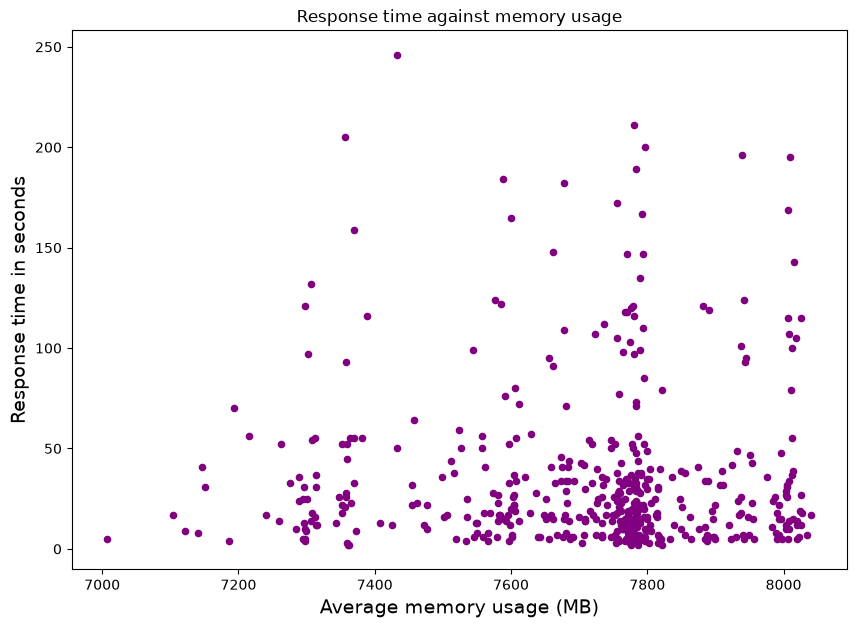

In [143]:
# scatter plot of Response Time against memory usage
completed_runs.plot(kind='scatter', x='memory_avg_mb',
                    y='model_time_seconds', color='purple',
                    figsize=(10, 7))
plt.xlabel('Average memory usage (MB)', size=14)
plt.ylabel('Response time in seconds', size=14)
plt.title('Response time against memory usage')
plt.show()

# Distribution analyses

In [80]:
# Prep work:
# Each model's response times are pulled into their own variable, so no name is reused across the analyses
# Response times for gemma-3-12b-it
gemma_response_times = completed_runs.loc[completed_runs['model'] == 'gemma-3-12b-it']['model_time_seconds']

# response times for pixtral-12b
pixtral_response_times = completed_runs.loc[completed_runs['model'] == 'pixtral-12b']['model_time_seconds']

# response times for minicpm-o-2_6
minicpm_response_times = completed_runs.loc[completed_runs['model'] == 'minicpm-o-2_6']['model_time_seconds']

# response times for qwen2-vl-7b-instruct
qwen_response_times = completed_runs.loc[completed_runs['model'] == 'qwen2-vl-7b-instruct']['model_time_seconds']

## Normal quantile plot of response time, one per model

  * Whether response time is normally distributed helps to prepare for the future analysis; this is the standard graphical test.

  * Two models can share a mean and behave differently in production if their shapes differ. Establishing the shape is part of describing how response time varies.

  * A right-skewed response time means the occasional very slow call could be related to an accident, and depends on timeouts and capacity.

  * `probplot(x, dist, plot)` compares the quantiles of the data against the quantiles of a theoretical distribution. `dist` defaults to `'norm'`. `plot` is where to draw the figures.

  *  **Findings:**

  * Plots bend upward in the upper right, supporting data skewed to the right, where the large values are larger than a normal distribution would produce. The shape is consistent across all four models even though their centers are different. Response time is not normally distributed, which affects the analysis method going forward.


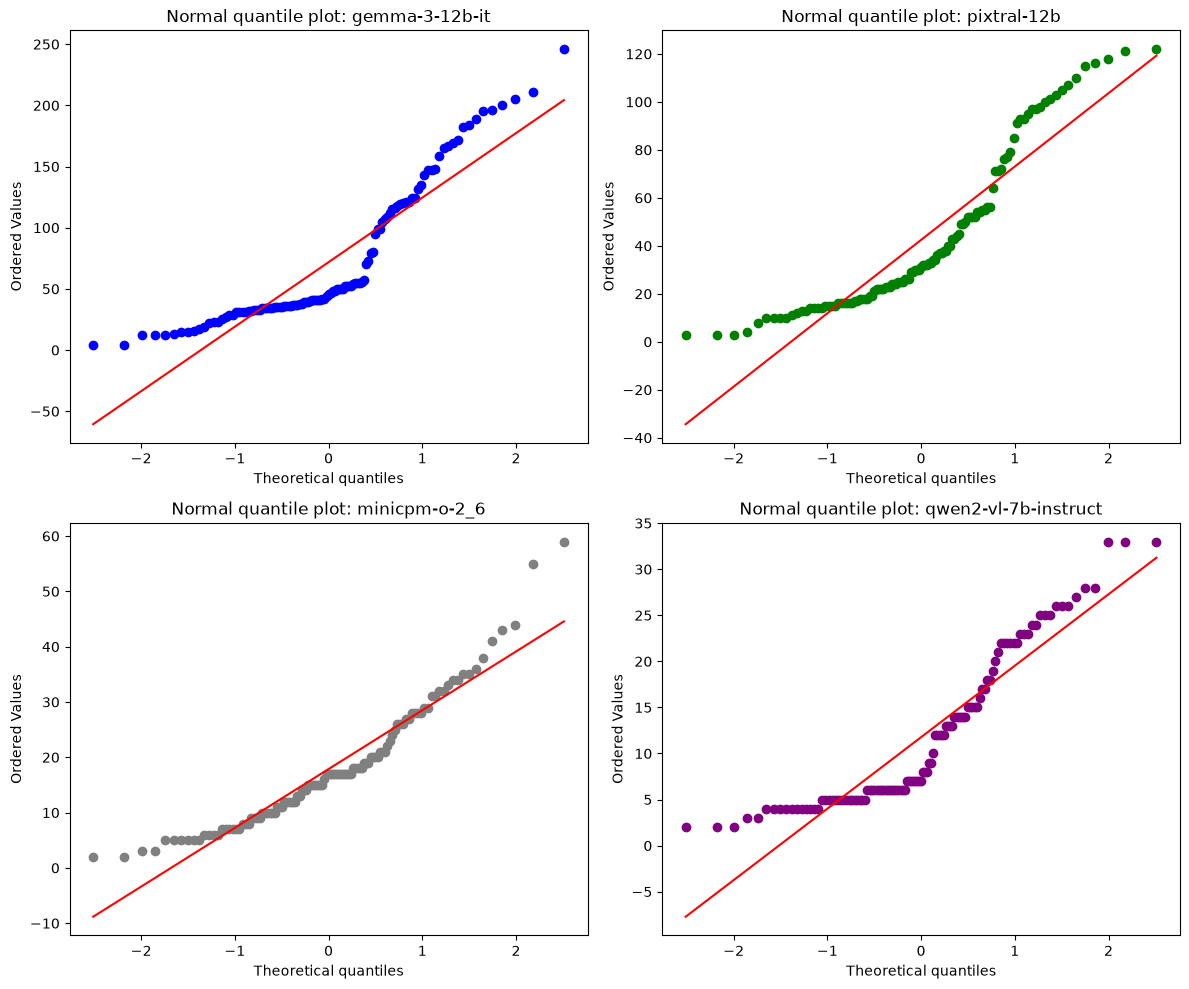

In [77]:
# Create plots
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
# normal quantile plot for gemma-3-12b-it
probplot(gemma_response_times, dist='norm', plot=pyplot)
plt.title('Normal quantile plot: gemma-3-12b-it')

plt.subplot(2, 2, 2)
# normal quantile plot for pixtral_response_times
probplot(pixtral_response_times, dist='norm', plot=pyplot)
plt.title('Normal quantile plot: pixtral-12b')
# Change the colors
ax = plt.gca()
ax.get_lines()[0].set_color('green')   # data points

plt.subplot(2, 2, 3)
# normal quantile plot for minicpm-o-2_6
probplot(minicpm_response_times, dist='norm', plot=pyplot)
plt.title('Normal quantile plot: minicpm-o-2_6')
# Change the colors
ax = plt.gca()
ax.get_lines()[0].set_color('gray')   # data points

plt.subplot(2, 2, 4)
# normal quantile plot for qwen2-vl-7b-instruct
probplot(qwen_response_times, dist='norm', plot=pyplot)
plt.title('Normal quantile plot: qwen2-vl-7b-instruct')
# Change the colors
ax = plt.gca()
ax.get_lines()[0].set_color('purple')   # data points

plt.tight_layout()
plt.show()

## Histogram of Response time against Gamma shapes

  * For the gamma densities `a = np.array([1, 2, 10])`, `sc = 10/a` and `scale = 1/lambda = mu/k`, and `ax.plot(x, gamma.pdf(x, a[i], 0, sc[i]), lw=2)`.

  * We established that the data are not normal and are right-skewed, suggesting a Gamma shape.

  *  In `plt.hist`, `density=True` puts proportions on the y-axis instead of counts so the histogram can be read on the same scale as a density curve; its default is `False`. `bins` is the number of equal-width bars; the matplotlib default is 10. In `gamma.pdf(x, a, loc, scale)`, `a` is the shape parameter the book labeled k, `loc` shifts the distribution and defaults to 0, and `scale` is 1/lambda and defaults to 1.

  *  **Findings:**

  * Every histogram rises sharply at the low end and trails off to the right. None is symmetric, and does not look like a normal distribution.
  * The Gemma (fastest model) mean of 71.84 seconds drives the three curves, giving scales of 71.84, 35.92 and 7.18 for shape values of 1, 2 and 10. 

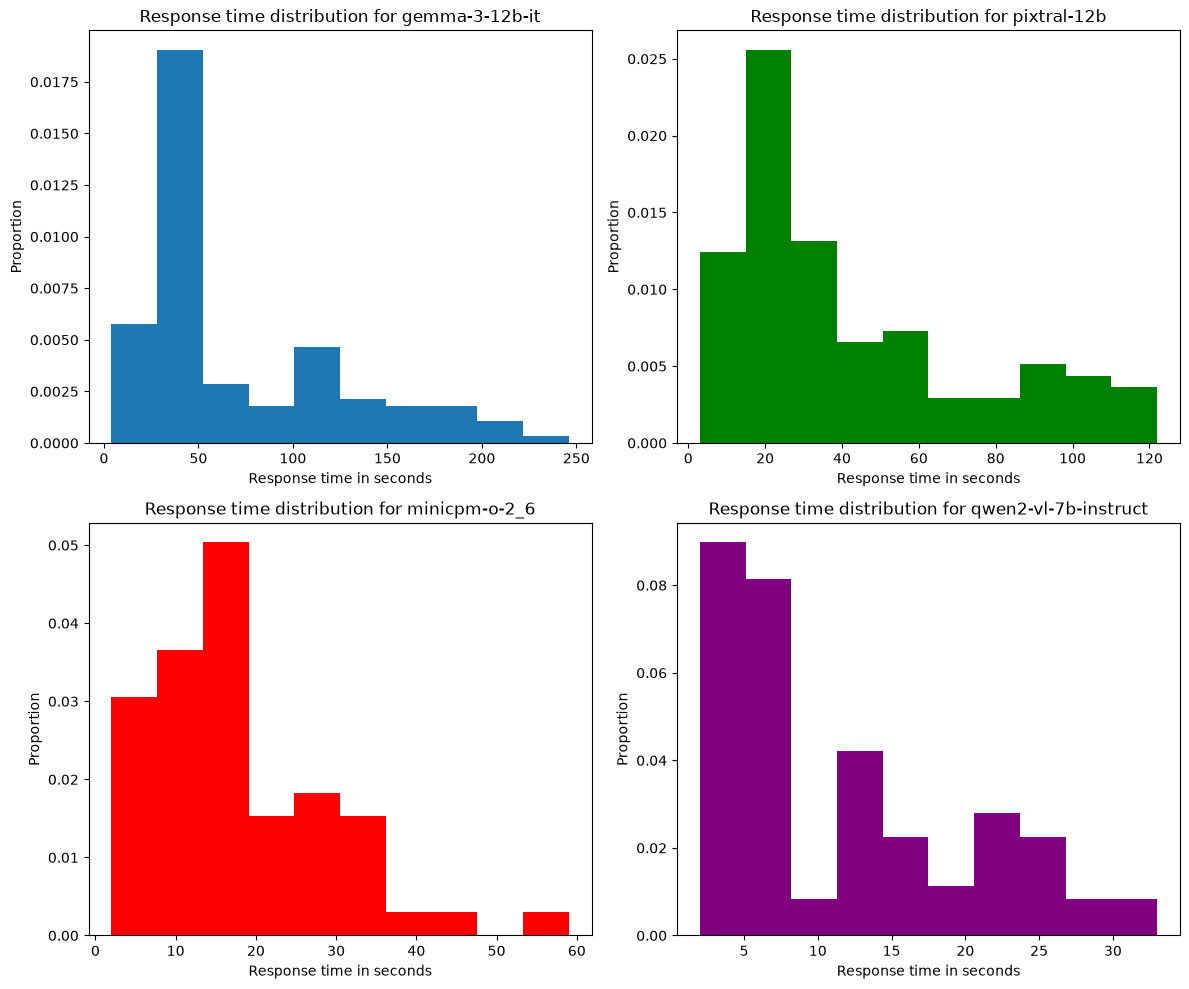

In [83]:
# Create plots for Response time distribution for each model
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
# Response time distribution for gemma-3-12b-it
plt.hist(gemma_response_times, density=True, bins=10)
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Response time distribution for gemma-3-12b-it')

plt.subplot(2, 2, 2)
# Response time distribution for pixtral-12b
plt.hist(pixtral_response_times, density=True, bins=10, color ="green")
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Response time distribution for pixtral-12b')

plt.subplot(2, 2, 3)
# Response time distribution for minicpm-o-2_6
plt.hist(minicpm_response_times, density=True, bins=10, color ="red")
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Response time distribution for minicpm-o-2_6')

plt.subplot(2, 2, 4)
# Response time distribution for qwen2-vl-7b-instruct
plt.hist(qwen_response_times, density=True, bins=10, color ="purple")
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Response time distribution for qwen2-vl-7b-instruct')

plt.tight_layout()
plt.show()

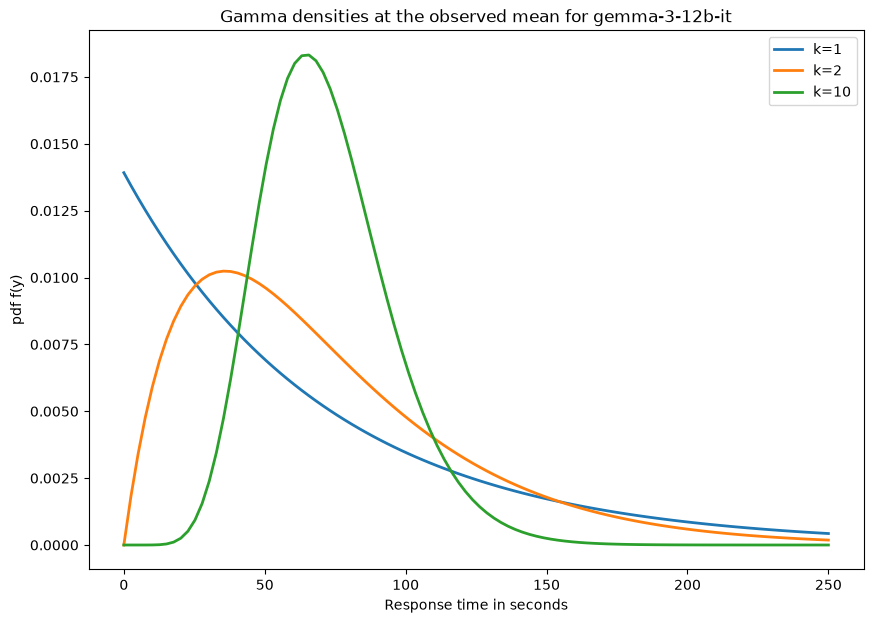

In [98]:
# We'll focus on the faster model gemma-3-12b-it
# Gamma distribution for gemma-3-12b-it's mean response time (they are similar for each model)
# Comparing the three shows which Gamma shape best matches the spread of the actual response times, 
# since the mean alone does not determine the distribution.
gemma_mean_response_time = gemma_response_times.mean()

# the three shape values
gamma_shape_values = np.array([1, 2, 10])

# scale = mu / k
gamma_scale_values = gemma_mean_response_time / gamma_shape_values

# range of response times to draw the curves over
response_times_to_draw = np.linspace(0, 250, 100)

# the figure and the axes to draw on, created together
gamma_figure, gamma_axes = plt.subplots(1, 1, figsize=(10, 7))

# one curve per shape value
for curve_number in range(3):
    gamma_axes.plot(
        response_times_to_draw,
        gamma.pdf(response_times_to_draw,
                  gamma_shape_values[curve_number], 0,
                  gamma_scale_values[curve_number]), lw=2)
    # k=1 - exponential distribution, highest at zero, falling steadily
    # k=2 - rise then a fall, strongly right-skewed
    # k=10 - hump, closer to symmetric
    gamma_axes.legend(['k=1', 'k=2', 'k=10'], loc='upper right')
plt.xlabel('Response time in seconds')
plt.ylabel('pdf f(y)')
plt.title('Gamma densities at the observed mean for gemma-3-12b-it')
plt.show()

## Response Times: Normal probability against the observed proportion

  *  We've learned that Response Times are not normal, but we cannot tell how much that matters.

  * We will ask a normal curve how many calls should finish within 1 minute, then ask our dataset the same question, and compare.

  * `norm.cdf(value, mu, sigma)` returns the probability of falling at or below `value`. `mu` defaults to 0 and `sigma` to 1, which together give the standard normal. `dropna()` removed every row with a missing value. 60 seconds are chosen for the threshold.

  *  **Findings:**
  * qwen2-vl-7b-instruct is the fastest model, by a wide margin and at every point of the distribution.

  * For predictability rather than just speed, minicpm-o-2_6 is the steadier choice. It is slower at the median but its times cluster more tightly, and a user would face less variation in what they wait.

For a normal curve with mean 71.84 and standard deviation 56.72, 0.42 of calls finish within 60 seconds.
 For gemma-3-12b-it, 0.65 of calls actually do.


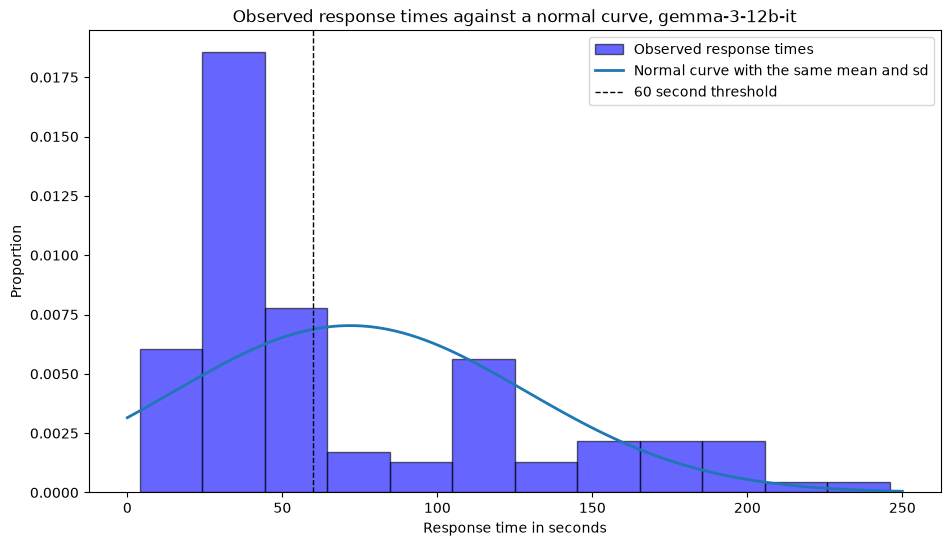

In [150]:
# Findings for gemma-3-12b-it

# The Response times that were actually recorded. Not Executed or Not Successful runs skipped.
gemma_recorded_times = gemma_response_times.dropna()

#  gemma-3-12b-it Mean of the recorded response times
gemma_mean_response_time = gemma_recorded_times.mean()
# gemma-3-12b-it Standard deviation of the recorded response times
gemma_sd_response_time = gemma_recorded_times.std()

# The threshold being tested - 60 seconds 
response_time_threshold = 60

# If gemma-3-12b-it response times followed a normal curve, what fraction of calls would finish within 60 seconds?
gemma_normal_share_under_threshold = norm.cdf(response_time_threshold, gemma_mean_response_time, gemma_sd_response_time)

# Each recorded run that finished at or under the threshold
gemma_runs_under_threshold = (gemma_recorded_times <= response_time_threshold)

# The share of gemma-3-12b-it that actually finished within the threshold
gemma_observed_share_under_threshold = gemma_runs_under_threshold.mean()

# Comparison at the threshold
print('For a normal curve with mean %.2f and standard deviation %.2f, '
      '%.2f of calls finish within %d seconds.\n For gemma-3-12b-it, '
      '%.2f of calls actually do.'
      % (gemma_mean_response_time, gemma_sd_response_time,
         gemma_normal_share_under_threshold, response_time_threshold,
         gemma_observed_share_under_threshold))

# Visualize results
# The range to draw the normal curve over, covering the observed times
curve_response_times = np.linspace(0, 250, 100)

# The normal curve's at each of those points.
normal_curve_heights = norm.pdf(curve_response_times, gemma_mean_response_time, gemma_sd_response_time)

# Plot figure
plt.figure(figsize=(11, 6))

# The observed times as a histogram.
plt.hist(gemma_recorded_times, density=True, bins=12, color ="blue", edgecolor='k', alpha=0.6, label='Observed response times')

# The normal curve on top of them.
plt.plot(curve_response_times, normal_curve_heights, lw=2, label='Normal curve with the same mean and sd')

# A vertical line at the threshold the comparison uses.
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')

# Label the axes
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Observed response times against a normal curve, gemma-3-12b-it')
plt.legend()

# Render
plt.show()

For a normal curve with mean 42.45 and standard deviation 32.35, 0.71 of calls finish within 60 seconds.
 For pixtral-12b, 0.77 of calls actually do.


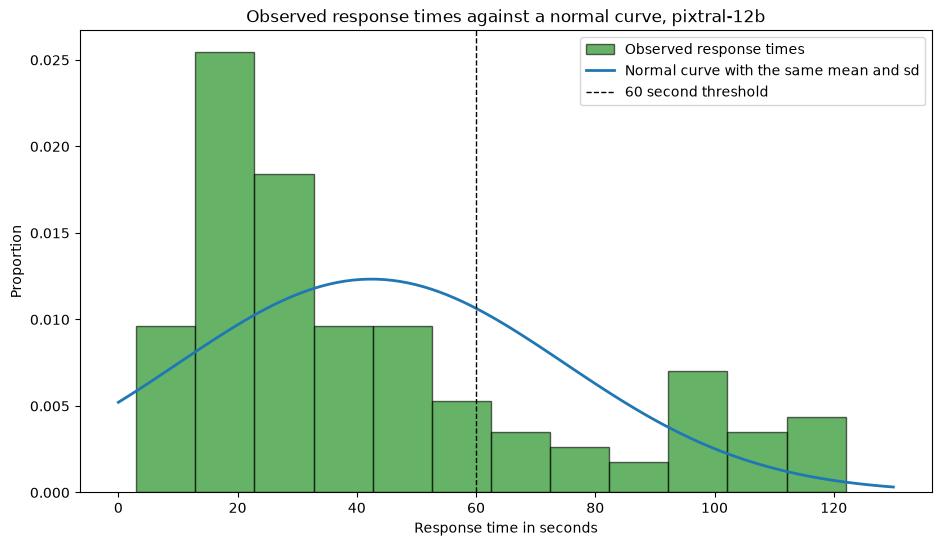

In [141]:
# Findings for pixtral-12b

# The Response times that were actually recorded. Not Executed or Not Successful runs skipped.
pixtral_recorded_times = pixtral_response_times.dropna()

#  pixtral-12b Mean of the recorded response times
pixtral_mean_response_time = pixtral_recorded_times.mean()
# pixtral-12b Standard deviation of the recorded response times
pixtral_sd_response_time = pixtral_recorded_times.std()

# The threshold being tested - 60 seconds 
response_time_threshold = 60

# If pixtral-12b response times followed a normal curve, what fraction of calls would finish within 60 seconds?
pixtral_normal_share_under_threshold = norm.cdf(response_time_threshold, pixtral_mean_response_time, pixtral_sd_response_time)

# Each recorded run that finished at or under the threshold
pixtral_runs_under_threshold = (pixtral_recorded_times <= response_time_threshold)

# The share of pixtral-12b that actually finished within the threshold
pixtral_observed_share_under_threshold = pixtral_runs_under_threshold.mean()

# Comparison at the threshold
print('For a normal curve with mean %.2f and standard deviation %.2f, '
      '%.2f of calls finish within %d seconds.\n For pixtral-12b, '
      '%.2f of calls actually do.'
      % (pixtral_mean_response_time, pixtral_sd_response_time,
         pixtral_normal_share_under_threshold, response_time_threshold,
         pixtral_observed_share_under_threshold))

# Visualize results
# The range to draw the normal curve over, covering the observed times
curve_response_times = np.linspace(0, 130, 100)

# The normal curve's at each of those points.
normal_curve_heights = norm.pdf(curve_response_times, pixtral_mean_response_time, pixtral_sd_response_time)

# Plot figure
plt.figure(figsize=(11, 6))

# The observed times as a histogram.
plt.hist(pixtral_recorded_times, density=True, bins=12, color ="green", edgecolor='k', alpha=0.6, label='Observed response times')

# The normal curve on top of them.
plt.plot(curve_response_times, normal_curve_heights, lw=2, label='Normal curve with the same mean and sd')

# A vertical line at the threshold the comparison uses.
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')

# Label the axes
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Observed response times against a normal curve, pixtral-12b')
plt.legend()

# Render
plt.show()

For a normal curve with mean 17.87 and standard deviation 10.94, 1.00 of calls finish within 60 seconds.
 For minicpm-o-2_6, 1.00 of calls actually do.


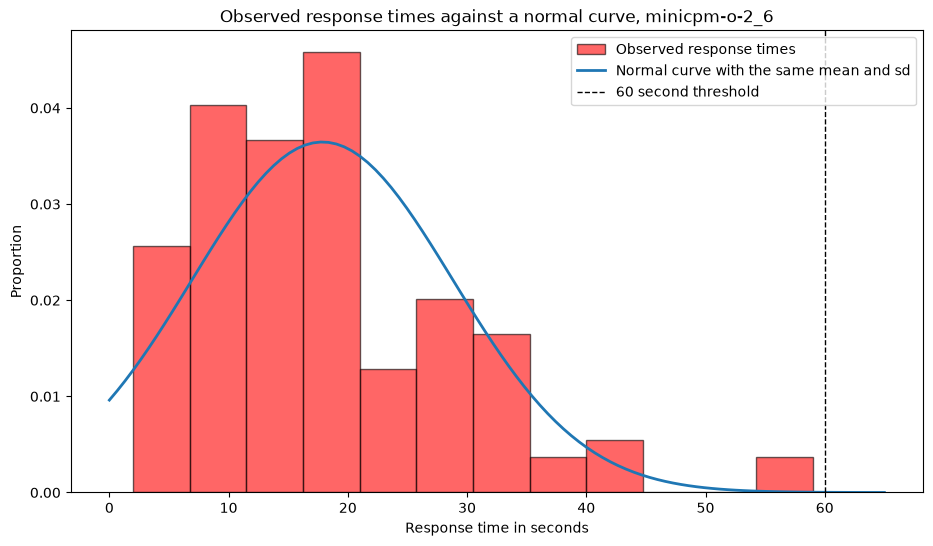

In [142]:
# Findings for minicpm-o-2_6

# The Response times that were actually recorded. 35 of the 150 runs have no time and dropped.
minicpm_recorded_times = minicpm_response_times.dropna()

#  minicpm-o-2_6 Mean of the recorded response times
minicpm_mean_response_time = minicpm_recorded_times.mean()
# minicpm-o-2_6 Standard deviation of the recorded response times
minicpm_sd_response_time = minicpm_recorded_times.std()

# The threshold being tested - 60 seconds 
response_time_threshold = 60

# If minicpm-o-2_6 response times followed a normal curve, what fraction of calls would finish within 60 seconds?
minicpm_normal_share_under_threshold = norm.cdf(response_time_threshold, minicpm_mean_response_time, minicpm_sd_response_time)

# Each recorded run that finished at or under the threshold
minicpm_runs_under_threshold = (minicpm_recorded_times <= response_time_threshold)

# The share of minicpm-o-2_6 that actually finished within the threshold
minicpm_observed_share_under_threshold = minicpm_runs_under_threshold.mean()

# Comparison at the threshold
print('For a normal curve with mean %.2f and standard deviation %.2f, '
      '%.2f of calls finish within %d seconds.\n For minicpm-o-2_6, '
      '%.2f of calls actually do.'
      % (minicpm_mean_response_time, minicpm_sd_response_time,
         minicpm_normal_share_under_threshold, response_time_threshold,
         minicpm_observed_share_under_threshold))

# Visualize results
# The range to draw the normal curve over, covering the observed times
curve_response_times = np.linspace(0, 65, 100)

# The normal curve's at each of those points.
normal_curve_heights = norm.pdf(curve_response_times, minicpm_mean_response_time, minicpm_sd_response_time)

# Plot figure
plt.figure(figsize=(11, 6))

# The observed times as a histogram.
plt.hist(minicpm_recorded_times, density=True, bins=12, color ="red", edgecolor='k', alpha=0.6, label='Observed response times')

# The normal curve on top of them.
plt.plot(curve_response_times, normal_curve_heights, lw=2, label='Normal curve with the same mean and sd')

# A vertical line at the threshold the comparison uses.
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')

# Label the axes
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Observed response times against a normal curve, minicpm-o-2_6')
plt.legend()

# Render
plt.show()

For a normal curve with mean 11.77 and standard deviation 8.20, 1.00 of calls finish within 60 seconds.
 For qwen2-vl-7b-instruct, 1.00 of calls actually do.


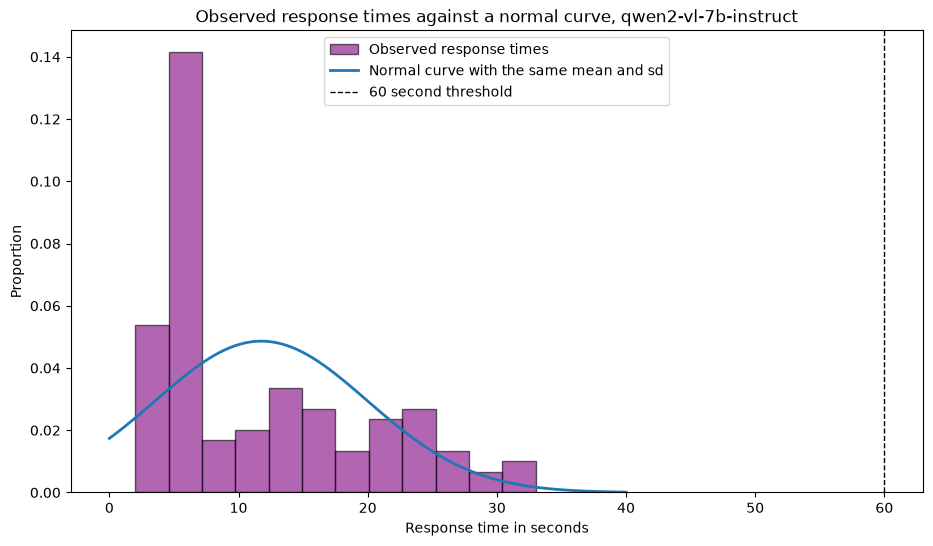

In [144]:
# Findings for qwen2-vl-7b-instruct

# The Response times that were actually recorded. 35 of the 150 runs have no time and dropped.
qwen_recorded_times = qwen_response_times.dropna()

#  qwen2-vl-7b-instruct Mean of the recorded response times
qwen_mean_response_time = qwen_recorded_times.mean()
# qwen2-vl-7b-instruct Standard deviation of the recorded response times
qwen_sd_response_time = qwen_recorded_times.std()

# The threshold being tested - 60 seconds 
response_time_threshold = 60

# If qwen2-vl-7b-instruct response times followed a normal curve, what fraction of calls would finish within 60 seconds?
qwen_normal_share_under_threshold = norm.cdf(response_time_threshold, qwen_mean_response_time, qwen_sd_response_time)

# Each recorded run that finished at or under the threshold
qwen_runs_under_threshold = (qwen_recorded_times <= response_time_threshold)

# The share of qwen2-vl-7b-instruct that actually finished within the threshold
qwen_observed_share_under_threshold = qwen_runs_under_threshold.mean()

# Comparison at the threshold
print('For a normal curve with mean %.2f and standard deviation %.2f, '
      '%.2f of calls finish within %d seconds.\n For qwen2-vl-7b-instruct, '
      '%.2f of calls actually do.'
      % (qwen_mean_response_time, qwen_sd_response_time,
         qwen_normal_share_under_threshold, response_time_threshold,
         qwen_observed_share_under_threshold))

# Visualize results
# The range to draw the normal curve over, covering the observed times
curve_response_times = np.linspace(0, 40, 100)

# The normal curve's at each of those points.
normal_curve_heights = norm.pdf(curve_response_times, qwen_mean_response_time, qwen_sd_response_time)

# Plot figure
plt.figure(figsize=(11, 6))

# The observed times as a histogram.
plt.hist(qwen_recorded_times, density=True, bins=12, color ="purple", edgecolor='k', alpha=0.6, label='Observed response times')

# The normal curve on top of them.
plt.plot(curve_response_times, normal_curve_heights, lw=2, label='Normal curve with the same mean and sd')

# A vertical line at the threshold the comparison uses.
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')

# Label the axes
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('Observed response times against a normal curve, qwen2-vl-7b-instruct')
plt.legend()

# Render
plt.show()

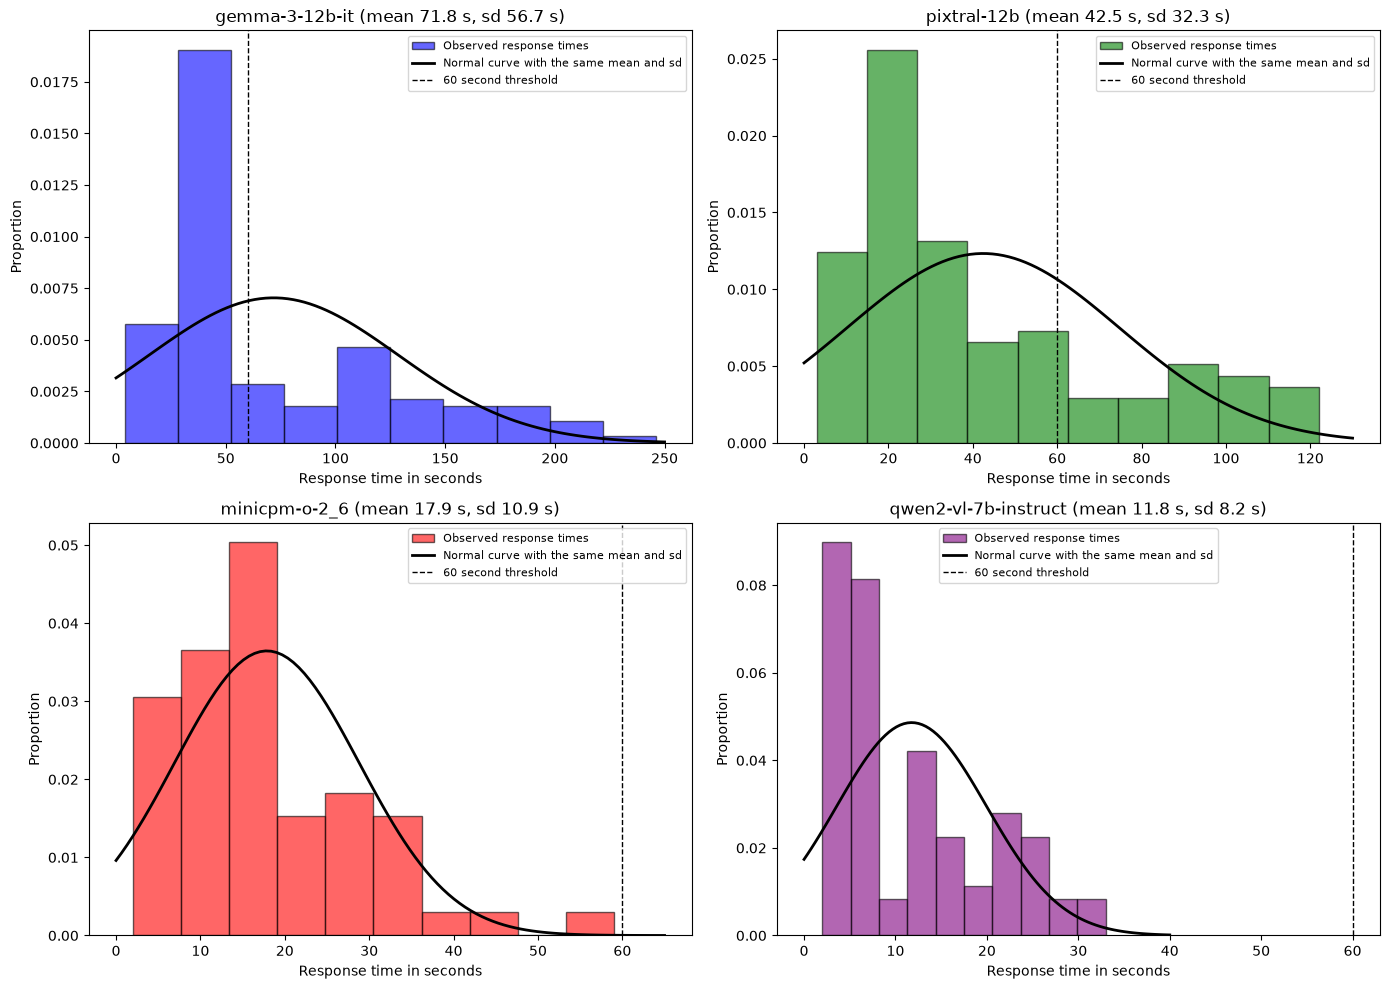

In [149]:
# Show previous findings together
# All four models in one figure, each with its own normal curve

# A figure large enough to hold a 2 by 2 grid
plt.figure(figsize=(14, 10))

# Top left - gemma-3-12b-it
plt.subplot(2, 2, 1)
gemma_curve_times = np.linspace(0, 250, 100)
gemma_curve_heights = norm.pdf(gemma_curve_times, gemma_mean_response_time,
                               gemma_sd_response_time)
plt.hist(gemma_recorded_times, density=True, bins=10, color="blue",
         edgecolor='k', alpha=0.6, label='Observed response times')
plt.plot(gemma_curve_times, gemma_curve_heights, lw=2, color='black',
         label='Normal curve with the same mean and sd')
# A vertical line at the threshold the comparison uses
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('gemma-3-12b-it (mean %.1f s, sd %.1f s)'
          % (gemma_mean_response_time, gemma_sd_response_time))
plt.legend(fontsize=8)

# Top right - pixtral-12b
plt.subplot(2, 2, 2)
pixtral_curve_times = np.linspace(0, 130, 100)
pixtral_curve_heights = norm.pdf(pixtral_curve_times,
                                 pixtral_mean_response_time,
                                 pixtral_sd_response_time)
plt.hist(pixtral_recorded_times, density=True, bins=10, color="green",
         edgecolor='k', alpha=0.6, label='Observed response times')
plt.plot(pixtral_curve_times, pixtral_curve_heights, lw=2, color='black',
         label='Normal curve with the same mean and sd')
# A vertical line at the threshold the comparison uses
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('pixtral-12b (mean %.1f s, sd %.1f s)'
          % (pixtral_mean_response_time, pixtral_sd_response_time))
plt.legend(fontsize=8)

# Bottom left - minicpm-o-2_6
plt.subplot(2, 2, 3)
minicpm_curve_times = np.linspace(0, 65, 100)
minicpm_curve_heights = norm.pdf(minicpm_curve_times,
                                 minicpm_mean_response_time,
                                 minicpm_sd_response_time)
plt.hist(minicpm_recorded_times, density=True, bins=10, color="red",
         edgecolor='k', alpha=0.6, label='Observed response times')
plt.plot(minicpm_curve_times, minicpm_curve_heights, lw=2, color='black',
         label='Normal curve with the same mean and sd')
# A vertical line at the threshold the comparison uses
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('minicpm-o-2_6 (mean %.1f s, sd %.1f s)'
          % (minicpm_mean_response_time, minicpm_sd_response_time))
plt.legend(fontsize=8)

# Bottom right - qwen2-vl-7b-instruct
plt.subplot(2, 2, 4)
qwen_curve_times = np.linspace(0, 40, 100)
qwen_curve_heights = norm.pdf(qwen_curve_times, qwen_mean_response_time,
                              qwen_sd_response_time)
plt.hist(qwen_recorded_times, density=True, bins=10, color="purple",
         edgecolor='k', alpha=0.6, label='Observed response times')
plt.plot(qwen_curve_times, qwen_curve_heights, lw=2, color='black',
         label='Normal curve with the same mean and sd')
# A vertical line at the threshold the comparison uses
plt.axvline(response_time_threshold, color='black', linestyle='--', lw=1,
            label='60 second threshold')
plt.ylabel('Proportion')
plt.xlabel('Response time in seconds')
plt.title('qwen2-vl-7b-instruct (mean %.1f s, sd %.1f s)'
          % (qwen_mean_response_time, qwen_sd_response_time))
plt.legend(fontsize=8)

# Space the panels so the titles and labels do not overlap
plt.tight_layout()

# Render the whole figure once, after all four panels are drawn
plt.show()

AI Disclosure:
  * ChatGPT was used on 10/4 to:

    * Look up model names, their meanings, and additional background information

    * Research how CPU usage, response time, and memory usage relate to model performance

    * Correct grammar and improve wording

    * Find different color options for box plots and Pyplot